In [1]:
import pandas as pd
from sklearn.datasets import load_wine
# Load Wine dataset
wine = load_wine()
X = wine.data
y = wine.target
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Accuracy (PCA + Poly SVM on Wine): 0.93


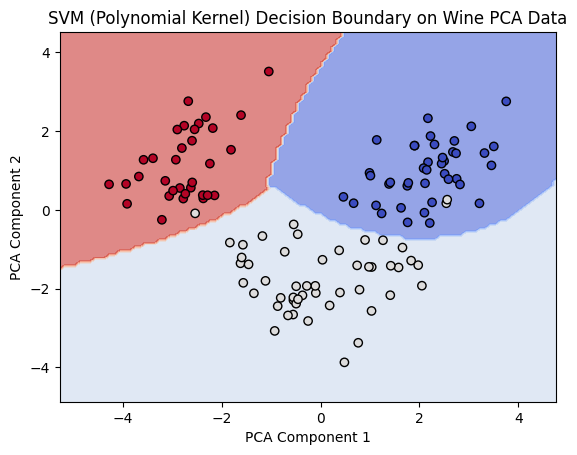

'Output -\nAccuracy (PCA + Poly SVM on Wine): 0.93\n'

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay
# Load Wine dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Dimensionality reduction to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)
# SVM with polynomial kernel
svm_poly = SVC(kernel="poly", degree=3, C=1.0, coef0=1)
svm_poly.fit(X_train, y_train)
# Accuracy
y_pred = svm_poly.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (PCA + Poly SVM on Wine): {accuracy:.2f}")
# Plot decision boundary
disp = DecisionBoundaryDisplay.from_estimator(
    svm_poly,
    X_train,
    response_method="predict",
    cmap=plt.cm.coolwarm,
    alpha=0.6,
    xlabel="PCA Component 1",
    ylabel="PCA Component 2"
)
# Scatter plot of training data
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap=plt.cm.coolwarm,
    edgecolors='k'
)
plt.title("SVM (Polynomial Kernel) Decision Boundary on Wine PCA Data")
plt.show()
'''Output -
Accuracy (PCA + Poly SVM on Wine): 0.93
'''
